In [1]:
import pandas as pd


In [2]:
from google.colab import files

In [3]:
uploaded = files.upload()

Saving dados_criminais_sao_paulo_2025.csv to dados_criminais_sao_paulo_2025.csv


In [4]:
df = pd.read_csv('dados_criminais_sao_paulo_2025.csv')

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# ausência do dado = ausência do evento
df['2025'] = df['2025'].fillna(0)

# O "bairro" não é uma coluna própria — vem embutido no nome da delegacia (DP),
# no formato "NNN DP - Nome do Bairro". Extraímos isso aqui.
df['bairro'] = df['DP'].str.split(' - ').str[-1].str.strip()

# 3 das 19 categorias de NATUREZA2 são "Nº DE VÍTIMAS EM ..." ( contam vítimas),
# não ocorrências (um homicídio pode ter mais de uma vítima). Somar isso junto
# duplicaria a contagem de homicídio doloso, latrocínio etc. Separamos antes de somar
df_ocorrencias = df[~df['NATUREZA2'].str.startswith('Nº DE VÍTIMAS')].copy()

print(f"{df['bairro'].nunique()} bairros/delegacias | {df_ocorrencias.shape[0]} linhas de ocorrências em 2025")
df_ocorrencias.head()

94 bairros/delegacias | 11564 linhas de ocorrências em 2025


,2024,2025,NATUREZA2,DP,MUNICIPIO,MES,bairro
0,1.0,4.0,ESTUPRO DE VULNERÁVEL,001 DP - Sé,São Paulo,1,Sé
1,773.0,795.0,FURTO - OUTROS,001 DP - Sé,São Paulo,1,Sé
2,22.0,21.0,FURTO DE VEÍCULO,001 DP - Sé,São Paulo,1,Sé
3,NaN,1.0,HOMICÍDIO DOLOSO,001 DP - Sé,São Paulo,1,Sé
4,NaN,2.0,LESÃO CORPORAL CULPOSA - OUTRAS,001 DP - Sé,São Paulo,1,Sé


In [11]:
# Classificação aproximada dos 94 bairros em 4 perfis. não é um dado oficial,
# é uma categorização manual
PERFIL_BAIRRO = {
    'Sé': 'Central', 'Bom Retiro': 'Central', 'Campos Elísios': 'Central', 'Consolação': 'Central',
    'Cambuci': 'Central', 'Brás': 'Central', 'Pari': 'Central', 'Santa Cecília': 'Central',

    'Jardins': 'Nobre', 'Itaim Bibi': 'Nobre', 'Pinheiros': 'Nobre', 'Perdizes': 'Nobre',
    'Vila Mariana': 'Nobre', 'Vila Clementino': 'Nobre', 'Campo Belo': 'Nobre', 'Monções': 'Nobre', 'Congonhas': 'Nobre',

    'Aclimação': 'Classe Média', 'Alto da Moóca': 'Classe Média', 'Artur Alvim': 'Classe Média',
    'Belém': 'Classe Média', 'Butantã': 'Classe Média', 'Carandiru': 'Classe Média',
    'Casa Verde': 'Classe Média', 'Ceagesp': 'Classe Média', 'Freguesia do Ó': 'Classe Média',
    'Ipiranga': 'Classe Média', 'Jabaquara': 'Classe Média', 'Jaguaré': 'Classe Média',
    'Jardim Arpoador': 'Classe Média', 'Lapa': 'Classe Média', 'Parque Bristol': 'Classe Média',
    'Parque Novo Mundo': 'Classe Média', 'Parque São Jorge': 'Classe Média',
    'Parque São Lucas': 'Classe Média', 'Parque da Moóca': 'Classe Média',
    'Penha de França': 'Classe Média', 'Pirituba': 'Classe Média', 'Sacomã': 'Classe Média',
    'Santo Amaro': 'Classe Média', 'Socorro': 'Classe Média', 'Vale do Aricanduva': 'Classe Média',
    'Vila Alpina': 'Classe Média', 'Vila Carrão': 'Classe Média', 'Vila Diva': 'Classe Média',
    'Vila Ema': 'Classe Média', 'Vila Formosa': 'Classe Média', 'Vila Maria': 'Classe Média',
    'Vila Matilde': 'Classe Média', 'Vila Penteado': 'Classe Média',
    'Vila Pereira Barreto': 'Classe Média', 'Vila Santa Maria': 'Classe Média',
    'Vila Sonia': 'Classe Média','Tatuapé': 'Classe Média', 'Água Fria': 'Classe Média',

    'Americanópolis': 'Periférico', 'Campo Grande': 'Periférico', 'Campo Limpo': 'Periférico',
    'Capão Redondo': 'Periférico', 'Cidade A E Carvalho': 'Periférico', 'Cidade Ademar': 'Periférico',
    'Cidade Dutra': 'Periférico', 'Cidade Tiradentes': 'Periférico', 'Cohab Itaquera': 'Periférico',
    'Ermelino Matarazzo': 'Periférico', 'Guaianazes': 'Periférico', 'Heliópolis': 'Periférico',
    'Itaim Paulista': 'Periférico', 'Itaquera': 'Periférico', 'Jaraguá': 'Periférico',
    'Jardim Herculano': 'Periférico', 'Jardim Mirna': 'Periférico', 'Jardim Míriam': 'Periférico',
    'Jardim Noemia': 'Periférico', 'Jardim Robru': 'Periférico', 'Jardim das Imbuias': 'Periférico',
    'Jaçanã': 'Periférico', 'Lajeado': 'Periférico', 'Parelheiros': 'Periférico',
    'Parque Santo Antônio': 'Periférico', 'Parque São Rafael': 'Periférico',
    'Parque do Carmo': 'Periférico', 'Perus': 'Periférico', 'Ponte Rasa': 'Periférico',
    'Portal do Morumbi': 'Periférico', 'São Mateus': 'Periférico', 'São Miguel Paulista': 'Periférico',
    'Teotônio Vilela': 'Periférico', 'Vila Amália': 'Periférico', 'Vila Brasilândia': 'Periférico',
    'Vila Gustavo': 'Periférico', 'Vila Jacuí': 'Periférico', 'Vila Joaniza': 'Periférico',
    'Vila Rica': 'Periférico',
}

df_ocorrencias['perfil_bairro'] = df_ocorrencias['bairro'].map(PERFIL_BAIRRO)

# confere se algum bairro ficou sem classificação
sem_classificacao = df_ocorrencias.loc[df_ocorrencias['perfil_bairro'].isna(), 'bairro'].unique()
print("Bairros sem classificação:", sem_classificacao if len(sem_classificacao) else "nenhum ✅")

ORDEM_PERFIL = ['Central', 'Nobre', 'Classe Média', 'Periférico']
CORES_PERFIL = {'Central': '#6C5B7B', 'Nobre': '#355C7D', 'Classe Média': '#F8B195', 'Periférico': '#C06C84'}

df_ocorrencias['perfil_bairro'].value_counts().reindex(ORDEM_PERFIL)

Bairros sem classificação: nenhum ✅


,count
perfil_bairro,
Central,955
Nobre,983
Classe Média,4521
Periférico,5105


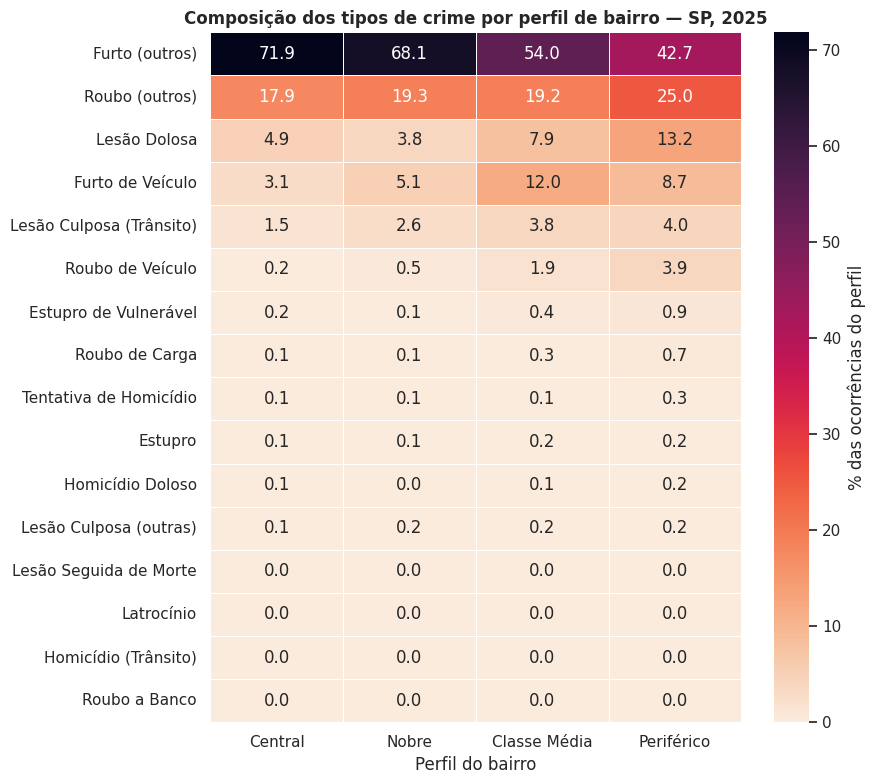

In [16]:
NOMES_CURTOS = {
    'ESTUPRO': 'Estupro', 'ESTUPRO DE VULNERÁVEL': 'Estupro de Vulnerável',
    'FURTO - OUTROS': 'Furto (outros)', 'FURTO DE VEÍCULO': 'Furto de Veículo',
    'HOMICÍDIO DOLOSO': 'Homicídio Doloso',
    'HOMICÍDIO DOLOSO POR ACIDENTE DE TRÂNSITO': 'Homicídio (Trânsito)',
    'LATROCÍNIO': 'Latrocínio', 'LESÃO CORPORAL CULPOSA - OUTRAS': 'Lesão Culposa (outras)',
    'LESÃO CORPORAL CULPOSA POR ACIDENTE DE TRÂNSITO': 'Lesão Culposa (Trânsito)',
    'LESÃO CORPORAL DOLOSA': 'Lesão Dolosa', 'LESÃO CORPORAL SEGUIDA DE MORTE': 'Lesão Seguida de Morte',
    'ROUBO - OUTROS': 'Roubo (outros)', 'ROUBO A BANCO': 'Roubo a Banco', 'ROUBO DE CARGA': 'Roubo de Carga',
    'ROUBO DE VEÍCULO': 'Roubo de Veículo', 'TENTATIVA DE HOMICÍDIO': 'Tentativa de Homicídio',
}
df_ocorrencias['crime'] = df_ocorrencias['NATUREZA2'].map(NOMES_CURTOS)

# tabela crime x perfil em % → "dentro deste perfil, que fatia das ocorrências é
# cada tipo de crime". Em % (não em total bruto) porque furto é volumoso em
# qualquer lugar e esconderia diferenças nos crimes mais raros.
pivot = df_ocorrencias.pivot_table(index='crime', columns='perfil_bairro', values='2025', aggfunc='sum', fill_value=0)
pivot = pivot[ORDEM_PERFIL]
pivot_pct = (pivot.div(pivot.sum(axis=0), axis=1) * 100).sort_values('Periférico', ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='rocket_r', linewidths=0.5,
            cbar_kws={'label': '% das ocorrências do perfil'}, ax=ax)
ax.set_title('Composição dos tipos de crime por perfil de bairro — SP, 2025', fontweight='bold')
ax.set_xlabel('Perfil do bairro'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

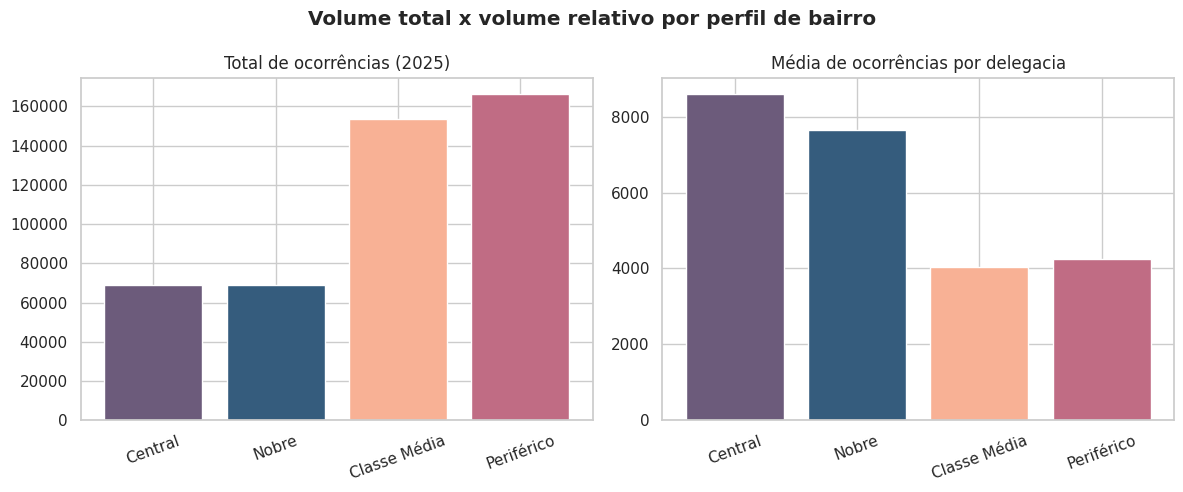

Delegacias por perfil: {'Central': 8, 'Nobre': 9, 'Classe Média': 38, 'Periférico': 39}


In [20]:
# Cuidado: os perfis têm números bem diferentes de delegacias (Periférico e Classe
# Média somam bem mais bairros que Central e Nobre). Comparar só o total favorece
# quem tem mais delegacias. Por isso mostramos total bruto E média por delegacia.
n_dp = df_ocorrencias.drop_duplicates('bairro')['perfil_bairro'].value_counts()
total_perfil = df_ocorrencias.groupby('perfil_bairro')['2025'].sum().reindex(ORDEM_PERFIL)
media_dp = total_perfil / n_dp.reindex(ORDEM_PERFIL)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(ORDEM_PERFIL, total_perfil.values, color=[CORES_PERFIL[p] for p in ORDEM_PERFIL])
axes[0].set_title('Total de ocorrências (2025)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(ORDEM_PERFIL, media_dp.values, color=[CORES_PERFIL[p] for p in ORDEM_PERFIL])
axes[1].set_title('Média de ocorrências por delegacia')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Volume total x volume relativo por perfil de bairro', fontweight='bold')
plt.tight_layout()
plt.show()

print("Delegacias por perfil:", n_dp.reindex(ORDEM_PERFIL).to_dict())

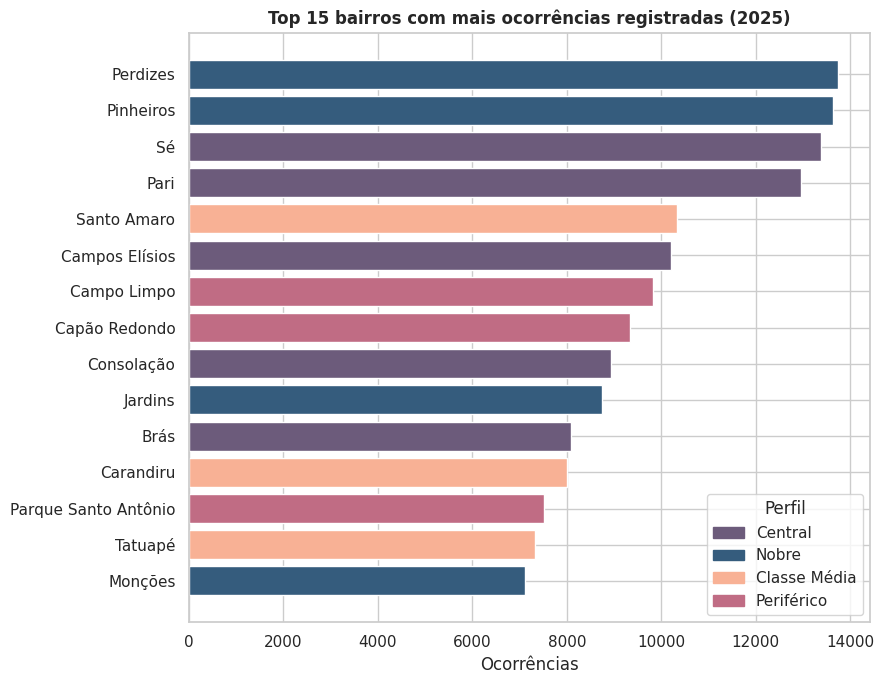

In [21]:
top_bairros = (df_ocorrencias.groupby(['bairro', 'perfil_bairro'])['2025']
               .sum().reset_index().sort_values('2025', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_bairros['bairro'], top_bairros['2025'],
        color=[CORES_PERFIL[p] for p in top_bairros['perfil_bairro']])
ax.invert_yaxis()
ax.set_title('Top 15 bairros com mais ocorrências registradas (2025)', fontweight='bold')
ax.set_xlabel('Ocorrências')
handles = [plt.Rectangle((0, 0), 1, 1, color=CORES_PERFIL[p]) for p in ORDEM_PERFIL]
ax.legend(handles, ORDEM_PERFIL, title='Perfil', loc='lower right')
plt.tight_layout()
plt.show()